# Tech Challenge Fase 1 - Case NPS Preditivo

Este notebook executa a entrega completa do desafio: entendimento do negocio,
definicao da variavel alvo, analise exploratoria com foco gerencial e uma
proposta de modelo preditivo para antecipar clientes com risco de se tornarem
detratores.


## 1. Entendimento do negocio

**Problema resolvido:** identificar quais fatores operacionais influenciam a
satisfacao dos clientes e criar uma forma de antecipar clientes com maior
risco de avaliacao negativa antes da pesquisa de NPS.

**Por que NPS importa para e-commerce:** o NPS resume a probabilidade de
recomendacao da marca e funciona como um termometro da experiencia completa:
compra, pagamento, entrega, atendimento e pos-venda. Em mercados digitais,
clientes insatisfeitos tendem a recomprar menos, reclamar mais e comparar
alternativas com muita facilidade.

**Areas beneficiadas:** logistica, atendimento, produto, pricing, CRM,
marketing de relacionamento e lideranca executiva. Cada area pode usar os
sinais para priorizar acoes preventivas e reduzir atritos na jornada.

**Impactos esperados:**
- Recompra: clientes promotores tendem a voltar mais vezes e com menor custo
  de aquisicao.
- Boca a boca: experiencias ruins aumentam reclamacoes e reduzem indicacao.
- Market share: em e-commerce, reputacao e experiencia influenciam escolha,
  recorrencia e migracao para concorrentes.

**Indicadores complementares:** SLA logistico, taxa de atraso, tempo medio de
resolucao, taxa de reclamacao, CSAT, recompra, benchmarks de NPS por setor,
avaliacoes publicas e indicadores de concorrencia.


In [1]:
from pathlib import Path
import json
import pickle
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    accuracy_score,
    confusion_matrix,
    precision_recall_fscore_support,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="Set2")

RANDOM_STATE = 42
TEST_SIZE = 0.25

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PATH = PROJECT_ROOT / "data" / "desafio_nps_fase_1.csv"
REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"
CHART_DATA_DIR = REPORTS_DIR / "chart_data"
MODELS_DIR = PROJECT_ROOT / "models"

for directory in [REPORTS_DIR, FIGURES_DIR, CHART_DATA_DIR, MODELS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)


## 2. Leitura e validacao da base

A primeira validacao garante que o arquivo utilizado corresponde ao escopo do
desafio: 2.500 registros, 19 variaveis e ausencia de valores nulos.


In [2]:
df = pd.read_csv(DATA_PATH)

expected_shape = (2500, 19)
assert df.shape == expected_shape, f"Shape inesperado: {df.shape}"
assert df.isna().sum().sum() == 0, "A base contem valores nulos"

df.head()


,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9


In [3]:
validation_summary = pd.DataFrame(
    {
        "metrica": [
            "linhas",
            "colunas",
            "valores_nulos",
            "nps_minimo",
            "nps_maximo",
            "nps_medio",
        ],
        "valor": [
            df.shape[0],
            df.shape[1],
            int(df.isna().sum().sum()),
            df["nps_score"].min(),
            df["nps_score"].max(),
            round(df["nps_score"].mean(), 2),
        ],
    }
)
validation_summary


,metrica,valor
0,linhas,2500.00
1,colunas,19.00
2,valores_nulos,0.00
3,nps_minimo,0.00
4,nps_maximo,10.00
5,nps_medio,4.38


## 3. Definicao da target

A variavel que representa satisfacao e `nps_score`, coletada apos a experiencia
de compra. Para a analise gerencial, ela e agrupada nas classes tradicionais:
detrator, neutro e promotor.

Para a modelagem, a target principal sera `is_detractor`, igual a 1 quando
`nps_score <= 6`. Essa escolha e acionavel: a empresa pode priorizar clientes
em risco, acionar atendimento proativo e corrigir falhas antes que a percepcao
negativa se consolide.

**Risco de uso inadequado:** variaveis coletadas depois da pesquisa, ou muito
proximas da propria satisfacao, podem inflar artificialmente o resultado do
modelo. Por isso, este notebook compara um cenario operacional sem sinais
potencialmente pos-jornada com outro cenario contendo `repeat_purchase_30d` e
`csat_internal_score`.


In [4]:
def classify_nps(score):
    if score <= 6:
        return "detrator"
    if score <= 8:
        return "neutro"
    return "promotor"


df = df.copy()
df["nps_class"] = df["nps_score"].apply(classify_nps)
df["is_detractor"] = (df["nps_score"] <= 6).astype(int)

nps_distribution = (
    df["nps_class"]
    .value_counts()
    .rename_axis("classe_nps")
    .reset_index(name="clientes")
)
nps_distribution["percentual"] = (
    nps_distribution["clientes"] / len(df) * 100
).round(2)

nps_score_distribution = (
    df["nps_score"]
    .round(1)
    .value_counts()
    .rename_axis("nps_score")
    .reset_index(name="clientes")
    .sort_values("nps_score")
)
nps_score_distribution["percentual"] = (
    nps_score_distribution["clientes"] / len(df) * 100
).round(2)

hist_counts, hist_edges = np.histogram(df["nps_score"], bins=20)
nps_score_histogram = pd.DataFrame(
    {
        "bin_inicio": hist_edges[:-1].round(4),
        "bin_fim": hist_edges[1:].round(4),
        "bin_centro": ((hist_edges[:-1] + hist_edges[1:]) / 2).round(4),
        "clientes": hist_counts,
    }
)

promoters = (df["nps_class"] == "promotor").mean() * 100
detractors = (df["nps_class"] == "detrator").mean() * 100
nps_index = round(promoters - detractors, 2)

nps_distribution.to_csv(REPORTS_DIR / "distribuicao_nps.csv", index=False)
nps_distribution.to_csv(CHART_DATA_DIR / "01a_distribuicao_classes_nps.csv", index=False)
nps_score_distribution.to_csv(CHART_DATA_DIR / "01b_distribuicao_notas_nps.csv", index=False)
nps_score_histogram.to_csv(CHART_DATA_DIR / "01c_histograma_nps_score_bins_20.csv", index=False)
print(f"NPS calculado da base: {nps_index}")
nps_distribution


NPS calculado da base: -66.0


,classe_nps,clientes,percentual
0,detrator,1851,74.04
1,neutro,448,17.92
2,promotor,201,8.04


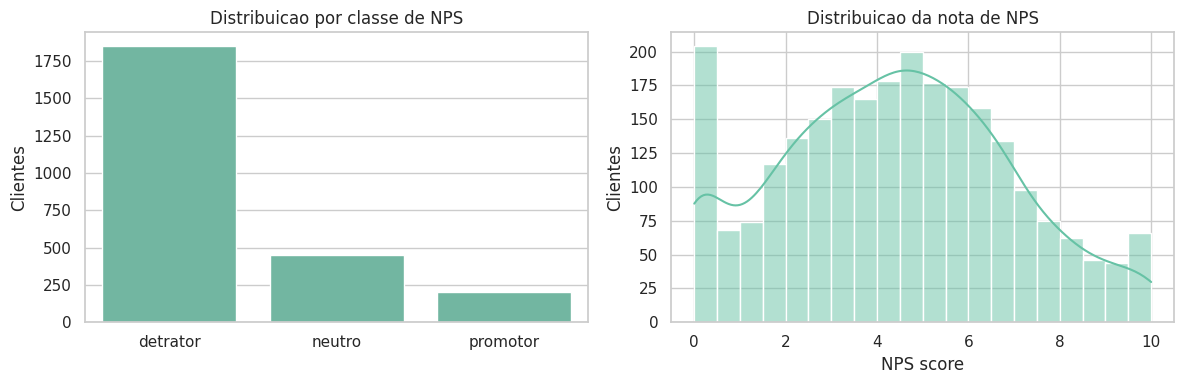

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

order = ["detrator", "neutro", "promotor"]
sns.countplot(data=df, x="nps_class", order=order, ax=axes[0])
axes[0].set_title("Distribuicao por classe de NPS")
axes[0].set_xlabel("")
axes[0].set_ylabel("Clientes")

sns.histplot(data=df, x="nps_score", bins=20, kde=True, ax=axes[1])
axes[1].set_title("Distribuicao da nota de NPS")
axes[1].set_xlabel("NPS score")
axes[1].set_ylabel("Clientes")

plt.tight_layout()
fig.savefig(FIGURES_DIR / "01_distribuicao_nps.png", dpi=160, bbox_inches="tight")
plt.show()


## 4. Analise exploratoria orientada a negocio

A EDA prioriza perguntas que gestores de operacao precisam responder:
quais fatores parecem reduzir a satisfacao, onde existe ponto de ruptura e
quais segmentos exigem mais atencao.


In [6]:
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()
corr_nps = (
    df[numeric_columns]
    .corr(numeric_only=True)["nps_score"]
    .drop(["nps_score", "is_detractor"])
    .sort_values(key=lambda s: s.abs(), ascending=False)
    .reset_index()
)
corr_nps.columns = ["variavel", "correlacao_com_nps"]
corr_nps.to_csv(REPORTS_DIR / "correlacoes_nps.csv", index=False)
corr_nps.to_csv(CHART_DATA_DIR / "02a_correlacoes_nps_completa.csv", index=False)
corr_nps.head(12)


,variavel,correlacao_com_nps
0,delivery_delay_days,-0.597260
1,repeat_purchase_30d,0.570324
2,csat_internal_score,0.563952
3,complaints_count,-0.496800
4,customer_service_contacts,-0.350845
5,resolution_time_days,-0.191392
6,freight_value,-0.041087
7,order_value,0.036990
8,delivery_attempts,0.027680
9,discount_value,0.025104


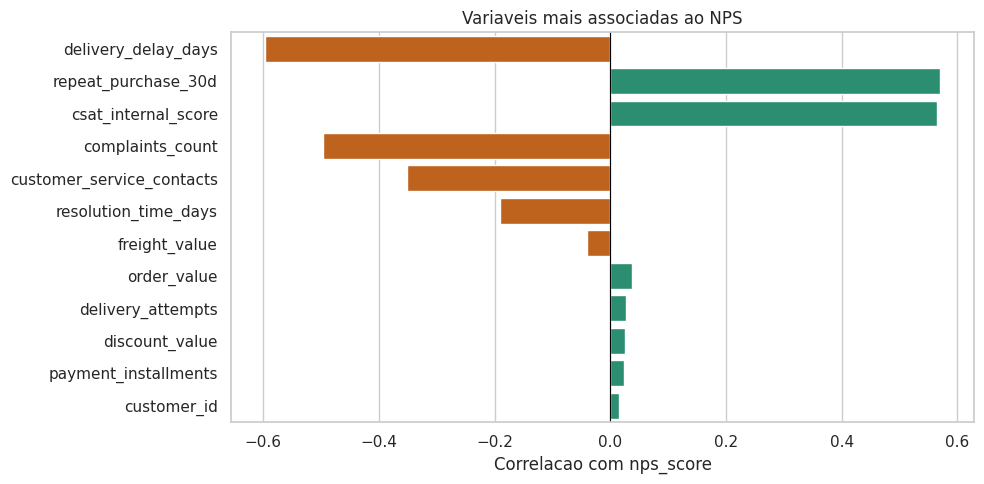

In [7]:
plt.figure(figsize=(10, 5))
top_corr = corr_nps.head(12).copy()
top_corr.to_csv(CHART_DATA_DIR / "02b_correlacoes_nps_top12.csv", index=False)
sns.barplot(
    data=top_corr,
    y="variavel",
    x="correlacao_com_nps",
    palette=["#d95f02" if value < 0 else "#1b9e77" for value in top_corr["correlacao_com_nps"]],
)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Variaveis mais associadas ao NPS")
plt.xlabel("Correlacao com nps_score")
plt.ylabel("")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_correlacoes_nps.png", dpi=160, bbox_inches="tight")
plt.show()


In [8]:
df_eda = df.copy()
df_eda["delay_bucket"] = pd.cut(
    df_eda["delivery_delay_days"],
    bins=[-np.inf, 0, 1, 3, 7, np.inf],
    labels=["sem atraso", "1 dia", "2-3 dias", "4-7 dias", "8+ dias"],
)
df_eda["complaints_bucket"] = pd.cut(
    df_eda["complaints_count"],
    bins=[-np.inf, 0, 1, 2, np.inf],
    labels=["0", "1", "2", "3+"],
)
df_eda["service_contacts_bucket"] = pd.cut(
    df_eda["customer_service_contacts"],
    bins=[-np.inf, 0, 1, 2, np.inf],
    labels=["0", "1", "2", "3+"],
)
df_eda["resolution_bucket"] = pd.cut(
    df_eda["resolution_time_days"],
    bins=[-np.inf, 2, 5, 10, np.inf],
    labels=["0-2 dias", "3-5 dias", "6-10 dias", "11+ dias"],
)
df_eda["age_band"] = pd.cut(
    df_eda["customer_age"],
    bins=[17, 29, 39, 49, 59, np.inf],
    labels=["18-29", "30-39", "40-49", "50-59", "60+"],
)
df_eda["tenure_band"] = pd.cut(
    df_eda["customer_tenure_months"],
    bins=[-np.inf, 6, 24, 60, np.inf],
    labels=["ate 6m", "7-24m", "25-60m", "60m+"],
)
df_eda["order_value_band"] = pd.qcut(
    df_eda["order_value"],
    q=4,
    labels=["baixo valor", "medio-baixo", "medio-alto", "alto valor"],
)


def summarize_by(column):
    return (
        df_eda.groupby(column, observed=True)
        .agg(
            clientes=("order_id", "count"),
            nps_medio=("nps_score", "mean"),
            taxa_detratores=("is_detractor", "mean"),
            recompra_30d=("repeat_purchase_30d", "mean"),
            atraso_medio=("delivery_delay_days", "mean"),
            reclamacoes_medias=("complaints_count", "mean"),
        )
        .reset_index()
        .assign(
            nps_medio=lambda d: d["nps_medio"].round(2),
            taxa_detratores=lambda d: (d["taxa_detratores"] * 100).round(2),
            recompra_30d=lambda d: (d["recompra_30d"] * 100).round(2),
            atraso_medio=lambda d: d["atraso_medio"].round(2),
            reclamacoes_medias=lambda d: d["reclamacoes_medias"].round(2),
        )
    )


factor_tables = []
for column in [
    "delay_bucket",
    "complaints_bucket",
    "service_contacts_bucket",
    "resolution_bucket",
]:
    table = summarize_by(column)
    table.insert(0, "fator", column)
    table = table.rename(columns={column: "faixa"})
    factor_tables.append(table)

critical_factors = pd.concat(factor_tables, ignore_index=True)
critical_factors.to_csv(REPORTS_DIR / "fatores_criticos_nps.csv", index=False)
critical_factors.to_csv(CHART_DATA_DIR / "03_fatores_criticos_taxa_detratores.csv", index=False)
critical_factors


,fator,faixa,clientes,nps_medio,taxa_detratores,recompra_30d,atraso_medio,reclamacoes_medias
0,delay_bucket,sem atraso,277,6.86,36.46,33.94,0.00,2.96
1,delay_bucket,1 dia,615,5.55,59.67,14.80,1.00,4.14
2,delay_bucket,2-3 dias,1171,4.07,81.81,2.73,2.45,4.28
3,delay_bucket,4-7 dias,434,2.01,97.24,0.23,4.52,4.56
4,delay_bucket,8+ dias,3,0.00,100.00,0.00,8.00,4.33
5,complaints_bucket,0,23,8.52,4.35,69.57,0.00,0.00
6,complaints_bucket,1,122,7.77,8.20,42.62,1.02,1.00
7,complaints_bucket,2,277,6.05,43.32,19.49,1.80,2.00
8,complaints_bucket,3+,2078,3.91,82.77,4.62,2.33,4.67
9,service_contacts_bucket,0,554,5.54,59.21,17.87,2.19,2.51


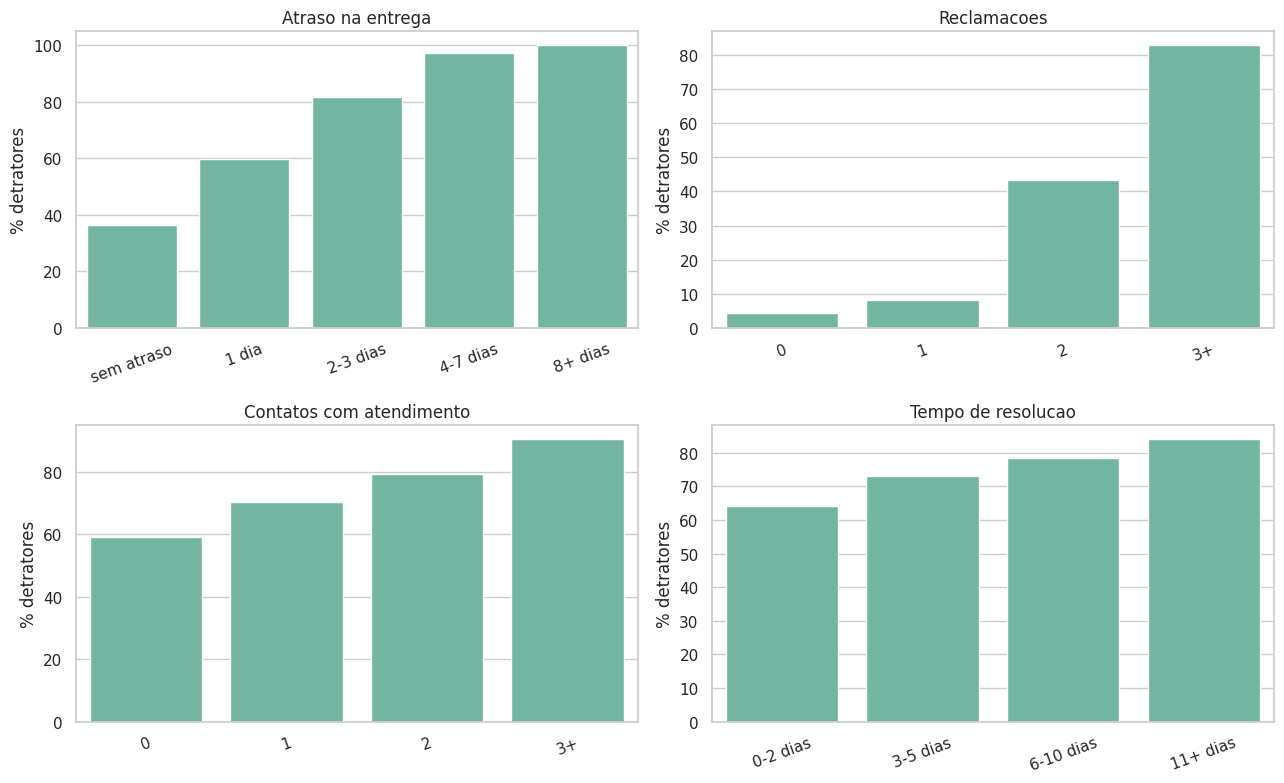

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
plot_specs = [
    ("delay_bucket", "Atraso na entrega"),
    ("complaints_bucket", "Reclamacoes"),
    ("service_contacts_bucket", "Contatos com atendimento"),
    ("resolution_bucket", "Tempo de resolucao"),
]

for ax, (column, title) in zip(axes.flat, plot_specs):
    table = summarize_by(column)
    sns.barplot(data=table, x=column, y="taxa_detratores", ax=ax)
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("% detratores")
    ax.tick_params(axis="x", rotation=20)

plt.tight_layout()
fig.savefig(FIGURES_DIR / "03_fatores_criticos.png", dpi=160, bbox_inches="tight")
plt.show()


In [10]:
segment_tables = []
for column in ["customer_region", "age_band", "tenure_band", "order_value_band"]:
    table = summarize_by(column)
    table.insert(0, "segmento", column)
    table = table.rename(columns={column: "faixa"})
    segment_tables.append(table)

segment_summary = pd.concat(segment_tables, ignore_index=True)
segment_summary.to_csv(REPORTS_DIR / "segmentos_nps.csv", index=False)
segment_summary


,segmento,faixa,clientes,nps_medio,taxa_detratores,recompra_30d,atraso_medio,reclamacoes_medias
0,customer_region,Centro-Oeste,468,4.21,74.36,8.33,2.22,4.18
1,customer_region,Nordeste,485,4.42,74.02,7.63,2.19,4.16
2,customer_region,Norte,506,4.38,74.51,7.91,2.14,4.11
3,customer_region,Sudeste,520,4.37,74.62,8.85,2.22,4.24
4,customer_region,Sul,521,4.49,72.74,10.75,2.17,4.06
5,age_band,18-29,561,4.54,73.44,8.91,2.15,4.09
6,age_band,30-39,498,4.22,76.51,8.23,2.23,4.19
7,age_band,40-49,496,4.27,74.60,7.06,2.26,4.18
8,age_band,50-59,482,4.37,72.20,9.54,2.20,4.22
9,age_band,60+,463,4.47,73.43,9.94,2.10,4.09


In [11]:
def threshold_lift(data, feature, target="is_detractor", min_share=0.08):
    rows = []
    values = sorted(data[feature].dropna().unique())
    for threshold in values[:-1]:
        lower = data[data[feature] <= threshold]
        higher = data[data[feature] > threshold]
        if len(lower) / len(data) < min_share or len(higher) / len(data) < min_share:
            continue
        rows.append(
            {
                "variavel": feature,
                "limite": threshold,
                "clientes_ate_limite": len(lower),
                "clientes_acima_limite": len(higher),
                "taxa_detrator_ate_limite": lower[target].mean() * 100,
                "taxa_detrator_acima_limite": higher[target].mean() * 100,
                "lift_pontos_percentuais": (higher[target].mean() - lower[target].mean()) * 100,
            }
        )
    if not rows:
        return None
    return max(rows, key=lambda row: abs(row["lift_pontos_percentuais"]))


rupture_features = [
    "delivery_delay_days",
    "complaints_count",
    "customer_service_contacts",
    "resolution_time_days",
    "delivery_attempts",
    "delivery_time_days",
]

rupture_rows = [
    threshold_lift(df, feature)
    for feature in rupture_features
]
rupture_table = pd.DataFrame([row for row in rupture_rows if row is not None])
numeric_cols = rupture_table.select_dtypes(include=np.number).columns
rupture_table[numeric_cols] = rupture_table[numeric_cols].round(2)
rupture_table = rupture_table.sort_values("lift_pontos_percentuais", ascending=False)
rupture_table.to_csv(REPORTS_DIR / "pontos_de_ruptura.csv", index=False)
rupture_table


,variavel,limite,clientes_ate_limite,clientes_acima_limite,taxa_detrator_ate_limite,taxa_detrator_acima_limite,lift_pontos_percentuais
1,complaints_count,2,422,2078,31.04,82.77,51.73
0,delivery_delay_days,0,277,2223,36.46,78.72,42.26
2,customer_service_contacts,2,2010,490,70.05,90.41,20.36
3,resolution_time_days,0,208,2292,60.10,75.31,15.21
5,delivery_time_days,2,203,2297,77.34,73.75,-3.59
4,delivery_attempts,2,1662,838,75.27,71.60,-3.67


In [12]:
strongest_negative = corr_nps[corr_nps["correlacao_com_nps"] < 0].head(5)
strongest_positive = corr_nps[corr_nps["correlacao_com_nps"] > 0].head(5)

delay_summary = summarize_by("delay_bucket")
complaints_summary = summarize_by("complaints_bucket")

print("Principais fatores que reduzem NPS:")
display(strongest_negative)
print("Principais fatores associados a NPS maior:")
display(strongest_positive)
print("Atraso e taxa de detratores:")
display(delay_summary)
print("Reclamacoes e taxa de detratores:")
display(complaints_summary)


Principais fatores que reduzem NPS:


,variavel,correlacao_com_nps
0,delivery_delay_days,-0.597260
3,complaints_count,-0.496800
4,customer_service_contacts,-0.350845
5,resolution_time_days,-0.191392
6,freight_value,-0.041087


Principais fatores associados a NPS maior:


,variavel,correlacao_com_nps
1,repeat_purchase_30d,0.570324
2,csat_internal_score,0.563952
7,order_value,0.036990
8,delivery_attempts,0.027680
9,discount_value,0.025104


Atraso e taxa de detratores:


,delay_bucket,clientes,nps_medio,taxa_detratores,recompra_30d,atraso_medio,reclamacoes_medias
0,sem atraso,277,6.86,36.46,33.94,0.00,2.96
1,1 dia,615,5.55,59.67,14.80,1.00,4.14
2,2-3 dias,1171,4.07,81.81,2.73,2.45,4.28
3,4-7 dias,434,2.01,97.24,0.23,4.52,4.56
4,8+ dias,3,0.00,100.00,0.00,8.00,4.33


Reclamacoes e taxa de detratores:


,complaints_bucket,clientes,nps_medio,taxa_detratores,recompra_30d,atraso_medio,reclamacoes_medias
0,0,23,8.52,4.35,69.57,0.00,0.00
1,1,122,7.77,8.20,42.62,1.02,1.00
2,2,277,6.05,43.32,19.49,1.80,2.00
3,3+,2078,3.91,82.77,4.62,2.33,4.67


## 5. Interpretacao gerencial da EDA

A leitura operacional deve priorizar tres perguntas:

1. **O que mais gera detratores?** atrasos, reclamacoes e muitos contatos com
   atendimento aparecem como sinais fortes de pior experiencia.
2. **Existe ponto de ruptura?** a tabela de pontos de ruptura mostra limites em
   que a taxa de detratores muda de patamar, apoiando definicao de SLAs e
   gatilhos de acao.
3. **Quem tende a ter NPS mais alto ou mais baixo?** a segmentacao por regiao,
   idade, valor do pedido e tempo de relacionamento ajuda a priorizar grupos
   de maior risco, sem transformar perfil demografico em justificativa unica.


## 6. Preparacao para modelagem

Serao comparados dois cenarios:

- **Operacional sem vazamento:** exclui `repeat_purchase_30d` e
  `csat_internal_score`, pois podem refletir eventos posteriores ou muito
  proximos da satisfacao final.
- **Com sinais pos-jornada:** inclui essas variaveis para demonstrar o quanto
  elas elevam a performance e por que devem ser usadas com cuidado em um
  modelo realmente preditivo.


In [13]:
target = "is_detractor"
id_columns = ["customer_id", "order_id"]
target_columns = ["nps_score", "nps_class", "is_detractor"]
leakage_risk_columns = ["repeat_purchase_30d", "csat_internal_score"]

scenarios = {
    "operacional_sem_vazamento": [
        column
        for column in df.columns
        if column not in id_columns + target_columns + leakage_risk_columns
    ],
    "com_sinais_pos_jornada": [
        column
        for column in df.columns
        if column not in id_columns + target_columns
    ],
}

for scenario_name, features in scenarios.items():
    assert "customer_id" not in features
    assert "order_id" not in features
    assert target not in features
    print(f"{scenario_name}: {len(features)} variaveis")
    print(features)


operacional_sem_vazamento: 14 variaveis
['customer_age', 'customer_region', 'customer_tenure_months', 'order_value', 'items_quantity', 'discount_value', 'payment_installments', 'delivery_time_days', 'delivery_delay_days', 'freight_value', 'delivery_attempts', 'customer_service_contacts', 'resolution_time_days', 'complaints_count']
com_sinais_pos_jornada: 16 variaveis
['customer_age', 'customer_region', 'customer_tenure_months', 'order_value', 'items_quantity', 'discount_value', 'payment_installments', 'delivery_time_days', 'delivery_delay_days', 'freight_value', 'delivery_attempts', 'customer_service_contacts', 'resolution_time_days', 'repeat_purchase_30d', 'complaints_count', 'csat_internal_score']


In [14]:
def make_one_hot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def make_preprocessor(data, features):
    categorical_features = data[features].select_dtypes(include=["object", "category"]).columns.tolist()
    numeric_features = [feature for feature in features if feature not in categorical_features]

    return ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), numeric_features),
            ("cat", make_one_hot_encoder(), categorical_features),
        ],
        remainder="drop",
    )


def make_models():
    return {
        "Dummy": DummyClassifier(strategy="most_frequent"),
        "LogisticRegression": LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=RANDOM_STATE,
        ),
        "RandomForest": RandomForestClassifier(
            n_estimators=300,
            min_samples_leaf=8,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
    }


## 7. Treino e avaliacao dos modelos

A separacao treino/teste e estratificada pela target para preservar a proporcao
de detratores. O `random_state` fixa a reprodutibilidade.


In [15]:
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test,
        y_pred,
        average="binary",
        pos_label=1,
        zero_division=0,
    )

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
        roc_auc = roc_auc_score(y_test, y_score)
    else:
        y_score = None
        roc_auc = np.nan

    return {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision_detrator": precision,
        "recall_detrator": recall,
        "f1_detrator": f1,
        "roc_auc": roc_auc,
        "y_pred": y_pred,
        "y_score": y_score,
    }


results = []
trained_models = {}
splits = {}

for scenario_name, features in scenarios.items():
    X = df[features]
    y = df[target]

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=TEST_SIZE,
        stratify=y,
        random_state=RANDOM_STATE,
    )
    splits[scenario_name] = (X_train, X_test, y_train, y_test)

    for model_name, estimator in make_models().items():
        pipeline = Pipeline(
            steps=[
                ("preprocess", make_preprocessor(df, features)),
                ("model", estimator),
            ]
        )
        pipeline.fit(X_train, y_train)
        metrics = evaluate_model(pipeline, X_test, y_test)
        trained_models[(scenario_name, model_name)] = pipeline

        results.append(
            {
                "cenario": scenario_name,
                "modelo": model_name,
                "accuracy": metrics["accuracy"],
                "precision_detrator": metrics["precision_detrator"],
                "recall_detrator": metrics["recall_detrator"],
                "f1_detrator": metrics["f1_detrator"],
                "roc_auc": metrics["roc_auc"],
            }
        )

model_results = pd.DataFrame(results)
metric_columns = ["accuracy", "precision_detrator", "recall_detrator", "f1_detrator", "roc_auc"]
model_results[metric_columns] = model_results[metric_columns].round(4)
model_results = model_results.sort_values(["cenario", "roc_auc", "f1_detrator"], ascending=[True, False, False])
model_results.to_csv(REPORTS_DIR / "resultados_modelos.csv", index=False)
model_results.to_csv(CHART_DATA_DIR / "04d_resultados_modelos.csv", index=False)
model_results


,cenario,modelo,accuracy,precision_detrator,recall_detrator,f1_detrator,roc_auc
4,com_sinais_pos_jornada,LogisticRegression,0.8080,0.9214,0.8099,0.8621,0.8922
5,com_sinais_pos_jornada,RandomForest,0.8400,0.9116,0.8683,0.8894,0.8899
3,com_sinais_pos_jornada,Dummy,0.7408,0.7408,1.0000,0.8511,0.5000
1,operacional_sem_vazamento,LogisticRegression,0.7840,0.9227,0.7732,0.8414,0.8730
2,operacional_sem_vazamento,RandomForest,0.8160,0.9009,0.8445,0.8718,0.8677
0,operacional_sem_vazamento,Dummy,0.7408,0.7408,1.0000,0.8511,0.5000


In [16]:
operational_results = model_results[model_results["cenario"] == "operacional_sem_vazamento"]
best_operational_row = operational_results.sort_values(
    ["roc_auc", "f1_detrator"],
    ascending=False,
).iloc[0]
best_key = (best_operational_row["cenario"], best_operational_row["modelo"])
best_model = trained_models[best_key]
X_train, X_test, y_train, y_test = splits[best_key[0]]

best_metrics = evaluate_model(best_model, X_test, y_test)

confusion_matrix_table = (
    pd.DataFrame(
        confusion_matrix(y_test, best_metrics["y_pred"], labels=[0, 1]),
        index=["real_nao_detrator", "real_detrator"],
        columns=["previsto_nao_detrator", "previsto_detrator"],
    )
    .reset_index()
    .rename(columns={"index": "classe_real"})
)
confusion_matrix_table.to_csv(CHART_DATA_DIR / "04a_matriz_confusao_melhor_modelo.csv", index=False)


In [17]:
fpr, tpr, roc_thresholds = roc_curve(y_test, best_metrics["y_score"])
roc_curve_table = pd.DataFrame(
    {
        "fpr": fpr,
        "tpr": tpr,
        "threshold": np.where(np.isinf(roc_thresholds), np.nan, roc_thresholds),
        "threshold_infinito": np.isinf(roc_thresholds),
    }
)
roc_curve_table.to_csv(CHART_DATA_DIR / "04b_curva_roc_melhor_modelo.csv", index=False)

evaluation_points = pd.DataFrame(
    {
        "amostra_teste": np.arange(1, len(y_test) + 1),
        "y_real": y_test.to_numpy(),
        "y_previsto": best_metrics["y_pred"],
        "probabilidade_detrator": best_metrics["y_score"],
    }
)
evaluation_points.to_csv(CHART_DATA_DIR / "04c_predicoes_teste_melhor_modelo.csv", index=False)

print("Melhor modelo operacional:", best_key)
print(best_operational_row.to_dict())


Melhor modelo operacional: ('operacional_sem_vazamento', 'LogisticRegression')
{'cenario': 'operacional_sem_vazamento', 'modelo': 'LogisticRegression', 'accuracy': 0.784, 'precision_detrator': 0.9227, 'recall_detrator': 0.7732, 'f1_detrator': 0.8414, 'roc_auc': 0.873}


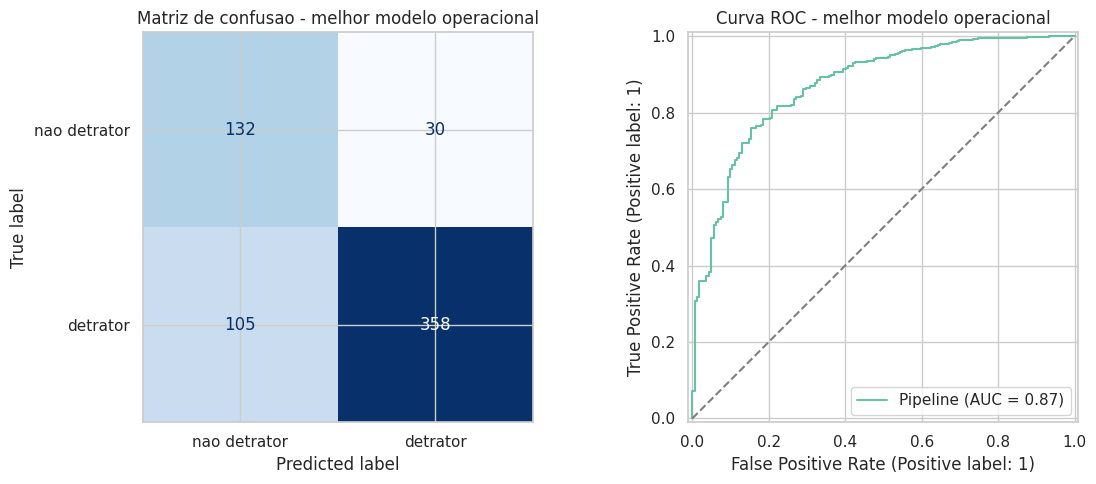

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    best_metrics["y_pred"],
    display_labels=["nao detrator", "detrator"],
    cmap="Blues",
    ax=axes[0],
    colorbar=False,
)
axes[0].set_title("Matriz de confusao - melhor modelo operacional")

RocCurveDisplay.from_estimator(best_model, X_test, y_test, ax=axes[1])
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[1].set_title("Curva ROC - melhor modelo operacional")

plt.tight_layout()
fig.savefig(FIGURES_DIR / "04_avaliacao_modelo.png", dpi=160, bbox_inches="tight")
plt.show()


In [19]:
def get_feature_names(pipeline):
    preprocessor = pipeline.named_steps["preprocess"]
    try:
        names = preprocessor.get_feature_names_out()
    except AttributeError:
        names = []
        for name, transformer, columns in preprocessor.transformers_:
            if name == "num":
                names.extend(columns)
            elif name == "cat":
                encoded = transformer.get_feature_names_out(columns)
                names.extend(encoded)
        names = np.array(names)
    return [
        name.replace("num__", "").replace("cat__", "")
        for name in names
    ]


model_step = best_model.named_steps["model"]
feature_names = get_feature_names(best_model)

if hasattr(model_step, "feature_importances_"):
    importance_values = model_step.feature_importances_
else:
    importance_values = np.abs(model_step.coef_[0])

feature_importance = (
    pd.DataFrame(
        {
            "variavel": feature_names,
            "importancia": importance_values,
        }
    )
    .sort_values("importancia", ascending=False)
    .reset_index(drop=True)
)
feature_importance.to_csv(REPORTS_DIR / "importancia_variaveis.csv", index=False)
feature_importance.to_csv(CHART_DATA_DIR / "05a_importancia_variaveis_completa.csv", index=False)
feature_importance.head(15)


,variavel,importancia
0,complaints_count,1.537794
1,delivery_delay_days,1.393996
2,resolution_time_days,0.578295
3,customer_region_Centro-Oeste,0.218768
4,customer_region_Norte,0.175011
5,order_value,0.152732
6,customer_service_contacts,0.122486
7,customer_region_Nordeste,0.119877
8,customer_region_Sul,0.115888
9,delivery_attempts,0.091676


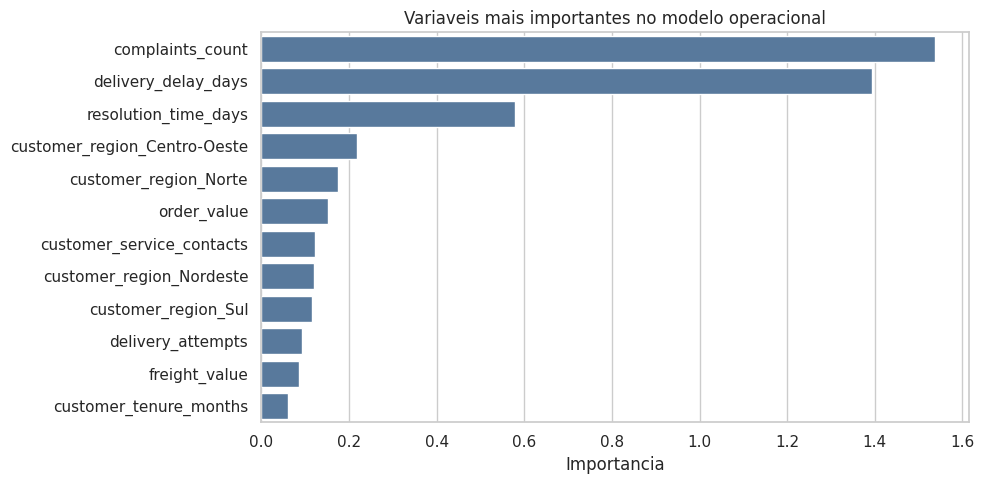

In [20]:
plt.figure(figsize=(10, 5))
top_importance = feature_importance.head(12)
top_importance.to_csv(CHART_DATA_DIR / "05b_importancia_variaveis_top12.csv", index=False)
sns.barplot(data=top_importance, y="variavel", x="importancia", color="#4c78a8")
plt.title("Variaveis mais importantes no modelo operacional")
plt.xlabel("Importancia")
plt.ylabel("")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "05_importancia_variaveis.png", dpi=160, bbox_inches="tight")
plt.show()


In [21]:
chart_data_manifest = pd.DataFrame(
    [
        {
            "grafico": "01_distribuicao_nps.png",
            "arquivo": "01a_distribuicao_classes_nps.csv",
            "conteudo": "contagem e percentual por classe de NPS",
        },
        {
            "grafico": "01_distribuicao_nps.png",
            "arquivo": "01b_distribuicao_notas_nps.csv",
            "conteudo": "contagem e percentual por nota de NPS arredondada em 1 decimal",
        },
        {
            "grafico": "01_distribuicao_nps.png",
            "arquivo": "01c_histograma_nps_score_bins_20.csv",
            "conteudo": "bins, centros e contagens do histograma de NPS com 20 bins",
        },
        {
            "grafico": "02_correlacoes_nps.png",
            "arquivo": "02a_correlacoes_nps_completa.csv",
            "conteudo": "correlacao de todas as variaveis numericas com nps_score",
        },
        {
            "grafico": "02_correlacoes_nps.png",
            "arquivo": "02b_correlacoes_nps_top12.csv",
            "conteudo": "top 12 correlacoes exibidas no grafico",
        },
        {
            "grafico": "03_fatores_criticos.png",
            "arquivo": "03_fatores_criticos_taxa_detratores.csv",
            "conteudo": "faixas operacionais, clientes, NPS medio e taxa de detratores",
        },
        {
            "grafico": "04_avaliacao_modelo.png",
            "arquivo": "04a_matriz_confusao_melhor_modelo.csv",
            "conteudo": "valores absolutos da matriz de confusao",
        },
        {
            "grafico": "04_avaliacao_modelo.png",
            "arquivo": "04b_curva_roc_melhor_modelo.csv",
            "conteudo": "pontos FPR, TPR e thresholds da curva ROC",
        },
        {
            "grafico": "04_avaliacao_modelo.png",
            "arquivo": "04c_predicoes_teste_melhor_modelo.csv",
            "conteudo": "classe real, classe prevista e probabilidade de detrator por amostra de teste",
        },
        {
            "grafico": "04_avaliacao_modelo.png",
            "arquivo": "04d_resultados_modelos.csv",
            "conteudo": "metricas comparativas dos modelos treinados",
        },
        {
            "grafico": "05_importancia_variaveis.png",
            "arquivo": "05a_importancia_variaveis_completa.csv",
            "conteudo": "importancia de todas as variaveis do modelo operacional",
        },
        {
            "grafico": "05_importancia_variaveis.png",
            "arquivo": "05b_importancia_variaveis_top12.csv",
            "conteudo": "top 12 importancias exibidas no grafico",
        },
    ]
)
chart_data_manifest.to_csv(CHART_DATA_DIR / "00_manifesto_dados_graficos.csv", index=False)
chart_data_manifest


,grafico,arquivo,conteudo
0,01_distribuicao_nps.png,01a_distribuicao_classes_nps.csv,contagem e percentual por classe de NPS
1,01_distribuicao_nps.png,01b_distribuicao_notas_nps.csv,contagem e percentual por nota de NPS arredond...
2,01_distribuicao_nps.png,01c_histograma_nps_score_bins_20.csv,"bins, centros e contagens do histograma de NPS..."
3,02_correlacoes_nps.png,02a_correlacoes_nps_completa.csv,correlacao de todas as variaveis numericas com...
4,02_correlacoes_nps.png,02b_correlacoes_nps_top12.csv,top 12 correlacoes exibidas no grafico
5,03_fatores_criticos.png,03_fatores_criticos_taxa_detratores.csv,"faixas operacionais, clientes, NPS medio e tax..."
6,04_avaliacao_modelo.png,04a_matriz_confusao_melhor_modelo.csv,valores absolutos da matriz de confusao
7,04_avaliacao_modelo.png,04b_curva_roc_melhor_modelo.csv,"pontos FPR, TPR e thresholds da curva ROC"
8,04_avaliacao_modelo.png,04c_predicoes_teste_melhor_modelo.csv,"classe real, classe prevista e probabilidade d..."
9,04_avaliacao_modelo.png,04d_resultados_modelos.csv,metricas comparativas dos modelos treinados


In [22]:
model_path = MODELS_DIR / "modelo_risco_detrator.pkl"
metadata_path = MODELS_DIR / "modelo_risco_detrator_metadata.json"

with model_path.open("wb") as file:
    pickle.dump(best_model, file)

model_metadata = {
    "objetivo": "Prever risco de cliente detrator de NPS",
    "target": "is_detractor = 1 quando nps_score <= 6",
    "cenario_escolhido": best_key[0],
    "modelo_escolhido": best_key[1],
    "features": scenarios[best_key[0]],
    "random_state": RANDOM_STATE,
    "test_size": TEST_SIZE,
    "metricas_teste": {
        key: float(value)
        for key, value in best_operational_row[metric_columns].to_dict().items()
    },
    "observacao_vazamento": (
        "repeat_purchase_30d e csat_internal_score foram excluidas do modelo operacional "
        "por risco de representarem sinais posteriores ou proximos demais da satisfacao."
    ),
}

metadata_path.write_text(json.dumps(model_metadata, indent=2, ensure_ascii=False), encoding="utf-8")
print(f"Modelo salvo em: {model_path.relative_to(PROJECT_ROOT)}")
print(f"Metadata salva em: {metadata_path.relative_to(PROJECT_ROOT)}")


Modelo salvo em: models/modelo_risco_detrator.pkl
Metadata salva em: models/modelo_risco_detrator_metadata.json


## 8. Como usar a solucao na pratica

1. Ao longo da jornada, consolidar dados de pedido, entrega e atendimento.
2. Rodar o modelo para gerar uma probabilidade de risco de detracao.
3. Priorizar clientes ou pedidos com maior risco para acoes preventivas.
4. Acionar times responsaveis: logistica para atraso, atendimento para
   reclamacoes/contatos recorrentes e CRM para comunicacao proativa.
5. Monitorar se a intervencao reduz detratores e aumenta recompra.

O modelo nao substitui a pesquisa de NPS; ele antecipa risco para que a
empresa tenha tempo de agir.


## 9. Recomendacoes executivas

- **Logistica:** criar gatilhos para pedidos com atraso ou multiplas tentativas
  de entrega, priorizando comunicacao proativa.
- **Atendimento:** tratar aumento de contatos e reclamacoes como alerta de
  experiencia, com fila priorizada para casos reincidentes.
- **Produto/Operacoes:** revisar causas-raiz de problemas que geram chamados
  e reclamacoes, nao apenas resolver caso a caso.
- **CRM:** usar risco de detracao para acoes personalizadas antes da pesquisa
  de NPS, evitando abordagem generica.
- **Gestao:** acompanhar NPS junto com SLA logistico, resolucao de atendimento,
  reclamacoes e recompra.


## 10. Limitacoes e riscos

- A base e historica e pode nao representar mudancas recentes da operacao.
- Correlacao nao prova causalidade; os insights devem orientar investigacao e
  priorizacao, nao conclusoes isoladas.
- Variaveis pos-jornada podem inflar metricas e nao devem ser usadas sem
  validar disponibilidade no momento da predicao.
- Como a maioria dos registros e detratora, e importante monitorar tambem
  falsos positivos, custo operacional e impacto real das intervencoes.
